In [ ]:
%load_ext autoreload
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(project_root)

from typing import Literal

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

from langgraph.constants import Send
from langgraph.graph import START, END, StateGraph
from langgraph.types import interrupt, Command

from src.open_deep_research.state import ReportStateInput, ReportStateOutput, Sections, ReportState, SectionState, SectionOutputState, Queries, Feedback, ToolsSectionState
from src.open_deep_research.prompts import report_planner_query_writer_instructions, report_planner_instructions, query_writer_instructions, section_writer_instructions, final_section_writer_instructions, section_grader_instructions
from src.open_deep_research.configuration import Configuration
from src.open_deep_research.utils import tavily_search_async, deduplicate_and_format_sources, format_sections, perplexity_search, parse_llm_response, langfuse_handler


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:


TICKER_REPORT_STRUCTURE = """The report structure should focus on breaking-down the user-provided ticker:

1. Introduction (no research needed)
   - Short overview of the ticker/company

2. Fundamental Analysis
    - Fundamentals of the company
          - Include any key concepts and definitions
   - Provide real-world examples or case studies where applicable
   - Based on the fundamental data, give a score between 1(weakest)-10(strongest)

3. Recent events that have affected the company
    - Recent negative news
    - Recent positive news

4. Upcoming events and earnings
    - Negative news
    - Positive news
    - Based on the recent and upcoming news you have gathered and analyzed, give a ranking between Low, Medium and High risk for the event risk of the stock

5. Our Advanced Metrics 
    - Use the tool "call_api" to get our advanced metrics for this company
    - Provide a table of the metrics

6. Conclusion
   - Provide a concise summary of the report
   - Provide a table providing the scores and rankings

   """

async def generate_report_plan(state: ReportState, config: RunnableConfig):
    """ Generate the report plan """

    # Inputs
    topic = state["topic"]
    feedback = state.get("feedback_on_report_plan", None)

    # Get configuration
    configurable = Configuration.from_runnable_config(config)
    report_structure = configurable.report_structure
    number_of_queries = configurable.number_of_queries

    print(configurable)
    # Convert JSON object to string if necessary
    if isinstance(report_structure, dict):
        report_structure = str(report_structure)

    writer_model = ChatOpenAI(model=configurable.writer_model)

    # Generate search query
    # structured_llm = writer_model.with_structured_output(Queries)

    # Format system instructions
    system_instructions_query = report_planner_query_writer_instructions.format(topic=topic, report_organization=report_structure, number_of_queries=number_of_queries)

    print("system_instructions_query:", system_instructions_query)
    # Generate queries  
    raw_results = writer_model.invoke([HumanMessage(content=system_instructions_query)],config={"callbacks": [langfuse_handler]})
    print(raw_results)
    results = parse_llm_response(raw_results.content, Queries)
    print(results)

    # Web search
    query_list = [query.search_query for query in results.queries]

    # Handle both cases for search_api:
    # 1. When selected in Studio UI -> returns a string (e.g. "tavily")
    # 2. When using default -> returns an Enum (e.g. SearchAPI.TAVILY)
    if isinstance(configurable.search_api, str):
        search_api = configurable.search_api
    else:
        search_api = configurable.search_api.value

    # Search the web
    if search_api == "tavily":
        search_results = await tavily_search_async(query_list)
        source_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=1000, include_raw_content=False)
    elif search_api == "perplexity":
        search_results = perplexity_search(query_list)
        source_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=1000, include_raw_content=False)
    else:
        raise ValueError(f"Unsupported search API: {configurable.search_api}")

    # Format system instructions
    system_instructions_sections = report_planner_instructions.format(topic=topic, report_organization=report_structure, context=source_str, feedback=feedback)
    print("system_instructions_sections:", system_instructions_sections)

    # Set the planner provider
    if isinstance(configurable.planner_provider, str):
        planner_provider = configurable.planner_provider
    else:
        planner_provider = configurable.planner_provider.value

    # Set the planner model
    if  planner_provider == "openai":
        planner_llm = ChatOpenAI(model=configurable.planner_model) 
    elif planner_provider == "groq":
        planner_llm = ChatGroq(model=configurable.planner_model)
    else:
        raise ValueError(f"Unsupported search API: {configurable.search_api}")

    # Generate sections 
    # structured_llm = planner_llm.with_structured_output(Sections)
    report_sections = planner_llm.invoke([HumanMessage(content=system_instructions_sections)], config={"callbacks": [langfuse_handler]})
    print(report_sections)

    parsed = parse_llm_response(report_sections.content, Sections)
    print(parsed)
    # Get sections
    sections = parsed.sections

    return {"sections": sections}



In [ ]:
def direct_graphs(state: ReportState, config: RunnableConfig) -> Command[Literal["generate_report_plan","build_section_with_web_research","build_section_with_tools"]]:

    sections = state['sections']
    topic = state['topic']
    gotos = []
    for s in sections:
        if s.tools:
            gotos.append(Send("build_section_with_tools", {"section": s}))
        else:
            gotos.append(Send("build_section_with_web_research", {"section": s, "search_iterations": 0}))


    return Command(goto=gotos)

In [41]:
from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

from langgraph.prebuilt import ToolNode
from typing import Literal
from langchain_core.tools.base import InjectedToolCallId

from langgraph.graph import StateGraph, MessagesState, START, END
from typing_extensions import Any, Annotated

@tool
def get_advanced_metrics(ticker: str,  tool_call_id: Annotated[str, InjectedToolCallId], config: RunnableConfig):
    """Call to get the advanced metrics"""
    if ticker.lower() in ["aapl", "bbai"]:
        mock_api_results = "Here are the advanced metrics for " + ticker + "Relative Volume: 100, Relative Strength: 100, Relative Sentiment: 100"
    else:
        mock_api_results = str({"ticker": ticker, "relativeStrength": "200", "relativeVolume": "200", "relativeSentiment": "2100"})
    return Command(
    update={
        # update the state keys
        "source_str": mock_api_results,
        # update the message history
        "messages": [ToolMessage("Successfully looked up ticker advanced metrics", tool_call_id=tool_call_id)]
    })

@tool
def get_custom_score(ticker: str,     tool_call_id: Annotated[str, InjectedToolCallId], config: RunnableConfig
):
    """Call to get the custom score"""
    if ticker.lower() in ["aapl", "bbai"]:
        mock_api_results = {"ticker": ticker, "customScore": 1}
    
    else:
        mock_api_results = {"ticker": ticker, "customScore": 2}
    return Command(
    update={
        # update the state keys
        "source_str": mock_api_results,
        # update the message history
        "messages": [ToolMessage("Successfully looked up ticker custom score", tool_call_id=tool_call_id)]
    })


def should_continue(state: SectionState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    
    # Update the existing section with new content and update search queries
    return  Command(
    update={"completed_sections": state['sections']},
    goto="search_web"
    )


def react_agent(state: SectionState):
    model = ChatOpenAI(model="gpt-3.5-turbo-16k")
    agent = create_react_agent(
        model,
        # pass the tool that can update state
        [get_advanced_metrics, get_custom_score],
        state_schema=SectionState,
        # pass dynamic prompt function
        # prompt=prompt,
    )

    agent.invoke(state, config={"callbacks": [langfuse_handler]})
    

In [42]:


def generate_queries(state: SectionState, config: RunnableConfig):
    """ Generate search queries for a report section """

    # Get state 
    section = state["section"]

    # Get configuration
    configurable = Configuration.from_runnable_config(config)
    writer_model = ChatOpenAI(model=configurable.writer_model)

    number_of_queries = configurable.number_of_queries

    # Generate queries 
    structured_llm = writer_model.with_structured_output(Queries)

    # Format system instructions
    system_instructions = query_writer_instructions.format(section_topic=section.description, number_of_queries=number_of_queries)

    # Generate queries  
    queries = structured_llm.invoke([SystemMessage(content=system_instructions)]+[HumanMessage(content="Generate search queries on the provided topic.")], config={"callbacks": [langfuse_handler]})

    return {"search_queries": queries.queries}

async def search_web(state: SectionState, config: RunnableConfig):
    """ Search the web for each query, then return a list of raw sources and a formatted string of sources."""
    
    # Get state 
    search_queries = state["search_queries"]

    # Get configuration
    configurable = Configuration.from_runnable_config(config)

    # Web search
    query_list = [query.search_query for query in search_queries]
    
    # Handle both cases for search_api:
    # 1. When selected in Studio UI -> returns a string (e.g. "tavily")
    # 2. When using default -> returns an Enum (e.g. SearchAPI.TAVILY)
    if isinstance(configurable.search_api, str):
        search_api = configurable.search_api
    else:
        search_api = configurable.search_api.value

    # Search the web
    if search_api == "tavily":
        search_results = await tavily_search_async(query_list)
        source_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=5000, include_raw_content=True)
    elif search_api == "perplexity":
        search_results = perplexity_search(query_list)
        source_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=5000, include_raw_content=False)
    else:
        raise ValueError(f"Unsupported search API: {configurable.search_api}")

    return {"source_str": source_str, "search_iterations": state["search_iterations"] + 1}


def write_section(state: SectionState, config: RunnableConfig) -> Command[Literal[END,"search_web"]]:
    """ Write a section of the report """

    # Get state 
    section = state["section"]
    source_str = state["source_str"]

    # Get configuration
    configurable = Configuration.from_runnable_config(config)
    writer_model = ChatOpenAI(model=configurable.writer_model)

    # Format system instructions
    system_instructions = section_writer_instructions.format(section_title=section.name, section_topic=section.description, context=source_str, section_content=section.content)

    # Generate section  
    section_content = writer_model.invoke([SystemMessage(content=system_instructions)]+[HumanMessage(content="Generate a report section based on the provided sources.")], config={"callbacks": [langfuse_handler]})
    print(section_content)

    # Write content to the section object  
    section.content = section_content.content

    # Grade prompt 
    section_grader_instructions_formatted = section_grader_instructions.format(section_topic=section.description,section=section.content)

    # Feedback 
    structured_llm = writer_model.with_structured_output(Feedback)
    feedback = structured_llm.invoke([SystemMessage(content=section_grader_instructions_formatted)]+[HumanMessage(content="Grade the report and consider follow-up questions for missing information:")], config={"callbacks": [langfuse_handler]})

    if feedback.grade == "pass" or state["search_iterations"] >= configurable.max_search_depth:
        # Publish the section to completed sections 
        return  Command(
        update={"completed_sections": [section]},
        goto=END
    )
    else:
        # Update the existing section with new content and update search queries
        return  Command(
        update={"search_queries": feedback.follow_up_queries, "section": section},
        goto="search_web"
        )



In [43]:

def write_final_sections(state: SectionState):
    """ Write final sections of the report, which do not require web search and use the completed sections as context """

    # Get state 
    section = state["section"]
    completed_report_sections = state["report_sections_from_research"]
    
    # Format system instructions
    system_instructions = final_section_writer_instructions.format(section_title=section.name, section_topic=section.description, context=completed_report_sections)

    # Generate section  
    section_content = writer_model.invoke([SystemMessage(content=system_instructions)]+[HumanMessage(content="Generate a report section based on the provided sources.")], config={"callbacks": [langfuse_handler]})
    
    # Write content to section 
    section.content = section_content.content

    # Write the updated section to completed sections
    return {"completed_sections": [section]}

def gather_completed_sections(state: ReportState):
    """ Gather completed sections from research and format them as context for writing the final sections """    

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = format_sections(completed_sections)

    return {"report_sections_from_research": completed_report_sections}

def initiate_final_section_writing(state: ReportState):
    """ Write any final sections using the Send API to parallelize the process """    

    # Kick off section writing in parallel via Send() API for any sections that do not require research
    return [
        Send("write_final_sections", {"section": s, "report_sections_from_research": state["report_sections_from_research"]}) 
        for s in state["sections"] 
        if not s.research and not s.tools
    ]

def compile_final_report(state: ReportState):
    """ Compile the final report """    

    # Get sections
    sections = state["sections"]
    completed_sections = {s.name: s.content for s in state["completed_sections"]}

    # Update sections with completed content while maintaining original order
    for section in sections:
        section.content = completed_sections[section.name]

    # Compile final report
    all_sections = "\n\n".join([s.content for s in sections])

    return {"final_report": all_sections}

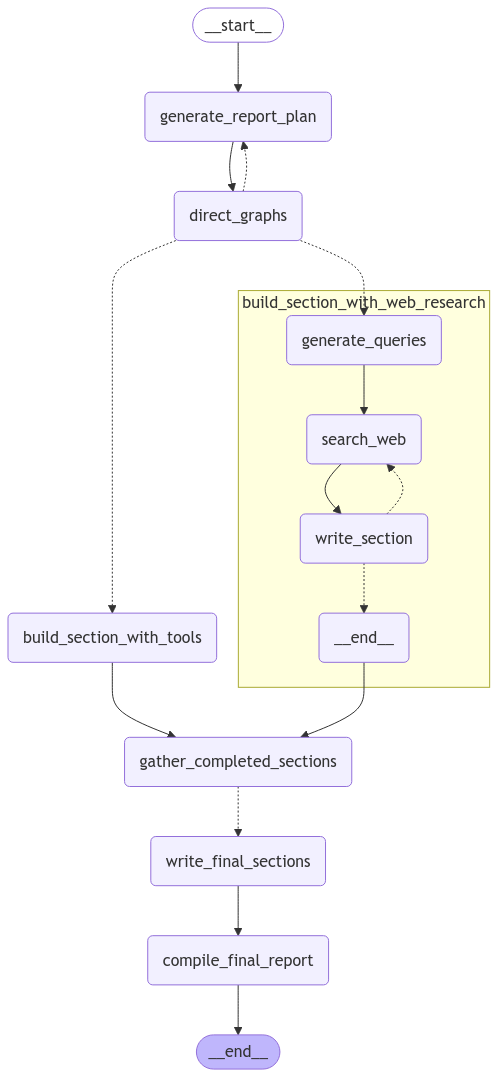

In [45]:
import asyncio

# Subgraph 1 --
# Add nodes 
section_builder = StateGraph(SectionState, output=SectionOutputState)
section_builder.add_node("generate_queries", generate_queries)
section_builder.add_node("search_web", search_web)
section_builder.add_node("write_section", write_section)

# Add edges
section_builder.add_edge(START, "generate_queries")
section_builder.add_edge("generate_queries", "search_web")
section_builder.add_edge("search_web", "write_section")

# Subgraph 21 --
# Add nodes 
section_builder_2 = StateGraph(SectionState, output=SectionOutputState)
section_builder_2.add_node("react_agent", react_agent)

# Add edges
section_builder_2.add_edge(START, "react_agent")
# section_builder.add_conditional_edges("react_agent", should_continue, ["tools", write_section])
# Outer graph -- 

# Add nodes
builder = StateGraph(ReportState, input=ReportStateInput, output=ReportStateOutput, config_schema=Configuration)
builder.add_node("generate_report_plan", generate_report_plan)
builder.add_node("direct_graphs", direct_graphs)
builder.add_node("build_section_with_web_research", section_builder.compile())
builder.add_node("build_section_with_tools", section_builder_2.compile())
builder.add_node("gather_completed_sections", gather_completed_sections)
builder.add_node("write_final_sections", write_final_sections)
builder.add_node("compile_final_report", compile_final_report)

# Add edges
builder.add_edge(START, "generate_report_plan")
builder.add_edge("generate_report_plan", "direct_graphs")
builder.add_edge("build_section_with_web_research", "gather_completed_sections")
builder.add_edge("build_section_with_tools", "gather_completed_sections")
builder.add_conditional_edges("gather_completed_sections", initiate_final_section_writing, ["write_final_sections"])
builder.add_edge("write_final_sections", "compile_final_report")
builder.add_edge("compile_final_report", END)
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)


# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))



In [ ]:
import uuid
topic = "AAPL"
# Fast config with o3-mini
thread = {"configurable": {"thread_id": str(uuid.uuid4()),
                           "report_structure": TICKER_REPORT_STRUCTURE,
                           "search_api": "tavily",
                           "planner_provider": "openai",
                           "max_search_depth": 1,
                           "writer_model": "o1-mini",
                           "planner_model": "o1-mini"}}

# Run the graph until the interruption
async for event in graph.astream({"topic":topic,}, thread, stream_mode="updates"):
    print(event)
    print("\n")

Configuration(report_structure='The report structure should focus on breaking-down the user-provided ticker:\n\n1. Introduction (no research needed)\n   - Short overview of the ticker/company\n\n2. Fundamental Analysis\n    - Fundamentals of the company\n          - Include any key concepts and definitions\n   - Provide real-world examples or case studies where applicable\n   - Based on the fundamental data, give a score between 1(weakest)-10(strongest)\n\n3. Recent events that have affected the company\n    - Recent negative news\n    - Recent positive news\n\n4. Upcoming events and earnings\n    - Negative news\n    - Positive news\n    - Based on the recent and upcoming news you have gathered and analyzed, give a ranking between Low, Medium and High risk for the event risk of the stock\n\n5. Our Advanced Metrics \n    - Use the tool "call_api" to get our advanced metrics for this company\n    - Provide a table of the metrics\n\n6. Conclusion\n   - Provide a concise summary of the re

Unexpected error occurred. Please check your request and contact support: https://langfuse.com/support.


content='```json\n{\n  "queries": [\n    {\n      "search_query": "Apple Inc fundamental analysis 2024 key financial metrics case studies"\n    },\n    {\n      "search_query": "Latest Apple news positive negative events 2024 upcoming earnings forecast"\n    }\n  ]\n}\n```' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 392, 'prompt_tokens': 440, 'total_tokens': 832, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'o1-mini-2024-09-12', 'system_fingerprint': 'fp_fc2f147b27', 'finish_reason': 'stop', 'logprobs': None} id='run-d2854400-48c0-4141-8226-ba08b9bcf0f6-0' usage_metadata={'input_tokens': 440, 'output_tokens': 392, 'total_tokens': 832, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 320}}
queries=[SearchQuery(

Unexpected error occurred. Please check your request and contact support: https://langfuse.com/support.


content='```json\n{\n  "sections": [\n    {\n      "name": "Introduction",\n      "description": "Short overview of the ticker/company.",\n      "research": false,\n      "tools": false,\n      "content": ""\n    },\n    {\n      "name": "Fundamental Analysis",\n      "description": "Exploration of the company\'s fundamentals, including key concepts and definitions, real-world examples or case studies, and a fundamental score based on the analysis.",\n      "research": true,\n      "tools": false,\n      "content": ""\n    },\n    {\n      "name": "Recent events that have affected the company",\n      "description": "Analysis of recent negative and positive news impacting the company.",\n      "research": true,\n      "tools": false,\n      "content": ""\n    },\n    {\n      "name": "Upcoming events and earnings",\n      "description": "Discussion of upcoming negative and positive news, along with a risk ranking based on the gathered and analyzed information.",\n      "research": true

Unexpected error occurred. Please check your request and contact support: https://langfuse.com/support.
Unexpected error occurred. Please check your request and contact support: https://langfuse.com/support.


In [ ]:
from src.open_deep_research.state import Section, Sections
import json
test = {'generate_report_plan': {'sections': [Section(name='Introduction', description='Short overview of the ticker/company.', research=False, content='', tools=False), Section(name='Fundamental Analysis', description="Analysis of the company's fundamentals, including key concepts and definitions, real-world examples or case studies, and an overall score based on the fundamental data.", research=True, content='', tools=False), Section(name='Recent events that have affected the company', description='Overview of recent negative and positive news impacting the company.', research=True, content='', tools=False), Section(name='Upcoming events and earnings', description='Information on upcoming negative and positive news, along with a risk ranking based on recent and upcoming news.', research=True, content='', tools=False), Section(name='Our Advanced Metrics', description='Advanced metrics for the company obtained through API calls and presented in a table format.', research=False, content='', tools=True), Section(name='Conclusion', description='Concise summary of the report, including a table of scores and rankings.', research=False, content='', tools=False)]}}
test

output = {'generate_report_plan': {'sections': [Section(name='Introduction', description='Short overview of the ticker/company.', research=False, content='', tools=False),
   Section(name='Fundamental Analysis', description="Analysis of the company's fundamentals, including key concepts and definitions, real-world examples or case studies, and an overall score based on the fundamental data.", research=True, content='', tools=False),
   Section(name='Recent events that have affected the company', description='Overview of recent negative and positive news impacting the company.', research=True, content='', tools=False),
   Section(name='Upcoming events and earnings', description='Information on upcoming negative and positive news, along with a risk ranking based on recent and upcoming news.', research=True, content='', tools=False),
   Section(name='Our Advanced Metrics', description='Advanced metrics for the company obtained through API calls and presented in a table format.', research=False, content='', tools=True),
   Section(name='Conclusion', description='Concise summary of the report, including a table of scores and rankings.', research=False, content='', tools=False)]}}

{'generate_report_plan': {'sections': [Section(name='Introduction', description='Short overview of the ticker/company.', research=False, content='', tools=False),
   Section(name='Fundamental Analysis', description="Analysis of the company's fundamentals, including key concepts and definitions, real-world examples or case studies, and an overall score based on the fundamental data.", research=True, content='', tools=False),
   Section(name='Recent events that have affected the company', description='Overview of recent negative and positive news impacting the company.', research=True, content='', tools=False),
   Section(name='Upcoming events and earnings', description='Information on upcoming negative and positive news, along with a risk ranking based on recent and upcoming news.', research=True, content='', tools=False),
   Section(name='Our Advanced Metrics', description='Advanced metrics for the company obtained through API calls and presented in a table format.', research=False, co